# Torchvision Faster R-CNN + training on COCO + evaluation (mAP)

## Limitations of Traditional CNNs for Object Detection

Traditional Convolutional Neural Networks (CNNs) that rely on fully connected layers often struggle with object detection tasks. This is especially true when an image contains multiple objects that vary in size and position.

A naive solution is the **sliding window approach**, where the model scans different parts of the image at multiple scales. However, this method is computationally expensive because:

- A large number of windows must be evaluated  
- The cost increases significantly with image size and scale variations  
- It does not scale efficiently for real-world detection problems  

---

## Introduction of R-CNN (Regions with CNN Features)

To address these challenges, **R-CNN** introduced a more efficient strategy.

Instead of exhaustively scanning the image, R-CNN uses a **selective search algorithm** to generate approximately **2,000 region proposals**. These regions are likely to contain objects.

Each proposed region is then:

1. Warped into a fixed size  
2. Passed through a CNN for feature extraction  
3. Classified to determine the object category  
4. Refined using bounding box regression  

---

## Why R-CNN Was Important

R-CNN marked a major improvement in object detection because:

- It dramatically reduced computation compared to sliding windows  
- It improved detection accuracy  
- It introduced the concept of region proposals + deep features  
- It laid the foundation for Fast R-CNN and Faster R-CNN  

R-CNN represents a key milestone in the evolution of modern object detection models.

In [ ]:
import torch
torch.cuda.is_available()


True

In [ ]:
!pip install pycocotools torchmetrics


### Downloading Small COCO Subset

In [2]:
# Creates a dedicated directory named coco and changes the working directory into it to organize the downloaded data.
!mkdir coco
%cd coco

/content/coco


In [ ]:
# donwload images (smaller validation set)
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip -q val2017.zip

In [ ]:
# download annotations
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q annotations_trainval2017.zip

In [5]:
%cd ..

/content


### Load Dataset

In [6]:
import torchvision
from torchvision.datasets import CocoDetection
import torchvision.transforms as T

transform = T.Compose([
    T.ToTensor()
])

dataset = CocoDetection(
    root="coco/val2017",
    annFile="coco/annotations/instances_val2017.json",
    transform=transform
)


loading annotations into memory...
Done (t=0.49s)
creating index...
index created!


### Reduce Dataset Size

In [7]:
from torch.utils.data import Subset

subset_indices = list(range(500))   # 500 images → safe for training
dataset = Subset(dataset, subset_indices)


### Collate Function

A helper function for the DataLoader. Standard DataLoaders try to stack data into a single tensor, but object detection requires variable-sized inputs (different numbers of boxes per image), so this function keeps them as tuples.

In [8]:
def collate_fn(batch):
    return tuple(zip(*batch))


### DataLoader

In [9]:
from torch.utils.data import DataLoader

# Creates the iterator that feeds data into the model. It uses a small batch size of 2 to conserve GPU memory and
# shuffles the data to improve training stability.

loader = DataLoader(
    dataset,
    batch_size=2,       # keep small for GPU memory
    shuffle=True,
    collate_fn=collate_fn
)


### Load Faster R-CNN

In [ ]:
# Loads a pre-trained Faster R-CNN model with a ResNet-50 backbone and a Feature Pyramid Network (FPN)
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)


### Optimzer

In [11]:
import torch.optim as optim

# Defines the Stochastic Gradient Descent (SGD) optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9)


### Training Loop

In [12]:
model.train()

for epoch in range(5):    # small epochs for demo (increase as required)
    total_loss = 0 # counter to track the cumulative loss for the current epoch

    for images, targets in loader:

        filtered_images = [] # List to hold images that contain valid objects
        filtered_targets = [] # List to hold formatted bounding boxes and labels for those images

        for img, t in zip(images, targets):

            boxes = [] # Temporary list to store converted bounding box coordinates
            labels = [] # Temporary list to store category IDs (classes)

            for obj in t:
                x, y, w, h = obj['bbox'] # Extracts COCO format: [top-left-x, top-left-y, width, height]
                boxes.append([x, y, x + w, y + h]) # Converts to Pascal VOC format: [xmin, ymin, xmax, ymax]
                labels.append(obj['category_id']) # Collects the class label for the object

            # Skip images with no objects
            if len(boxes) == 0:
                continue

            filtered_images.append(img.to(device))

            # # Creates a dictionary for each image containing tensors of boxes and labels
            filtered_targets.append({
                "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                "labels": torch.tensor(labels, dtype=torch.int64).to(device)
            })

        # Skip batch if everything was empty
        if len(filtered_images) == 0:
            continue

        # Forward pass: the model returns a dictionary of various losses (RPN loss, Box loss, etc.)
        loss_dict = model(filtered_images, filtered_targets)

        # Sums all individual losses (classification, regression, etc.) into a single scalar value
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad() # Clears previous gradients so they don't accumulate
        losses.backward() # Backpropagation: computes the gradient of the loss with respect to model parameters
        optimizer.step() # Update step: adjusts model weights based on the computed gradients

        total_loss += losses.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")


Epoch 1, Loss: 194.63
Epoch 2, Loss: 154.92
Epoch 3, Loss: 125.74
Epoch 4, Loss: 107.45
Epoch 5, Loss: 93.07


In [14]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
model.eval()
metric = MeanAveragePrecision()

In [15]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision # Imports the utility to calculate Mean Average Precision (mAP)
import torch # Imports the core PyTorch library

model.eval() # Sets the model to evaluation mode (disables dropout, uses population statistics for BatchNorm)
metric = MeanAveragePrecision().to(device)   # Initializes the mAP metric and moves its internal state to the GPU/CPU

with torch.no_grad(): # Disables gradient calculation to reduce memory usage and speed up inference

    for images, targets in loader: # Iterates through the evaluation dataset batches

        filtered_images = [] # List to hold images containing valid objects
        gt_targets = []      # List to hold the formatted ground-truth annotations

        for img, t in zip(images, targets): # Processes each image and its metadata in the batch

            boxes = []  # List for ground-truth bounding box coordinates
            labels = [] # List for ground-truth category labels

            for obj in t: # Loops through each annotated object in the current image
                x, y, w, h = obj['bbox'] # Extracts COCO format: [top-left-x, top-left-y, width, height]
                boxes.append([x, y, x + w, y + h]) # Converts to [xmin, ymin, xmax, ymax] required by Torchvision
                labels.append(obj['category_id']) # Stores the class ID for the object

            # Skips images that have no ground-truth objects to avoid evaluation errors
            if len(boxes) == 0:
                continue

            filtered_images.append(img.to(device)) # Moves the image tensor to the active device (e.g., T4 GPU)

            # Prepares the ground-truth dictionary in the format expected by torchmetrics
            gt_targets.append({
                "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),   # Converts boxes to FloatTensor
                "labels": torch.tensor(labels, dtype=torch.int64).to(device)     # Converts labels to LongTensor
            })

        # Skips the entire batch if no valid images remained after filtering
        if len(filtered_images) == 0:
            continue

        # Forward Pass: In eval mode, the model returns a list of dictionaries containing:
        # 'boxes' (detected coords), 'labels' (predicted classes), and 'scores' (confidence levels)
        preds = model(filtered_images)

        # Updates the metric state by comparing the model's predictions against the ground truth
        metric.update(preds, gt_targets)

# Calculates the final metrics (mAP, mAP_50, mAP_75, etc.) based on all updated batches
results = metric.compute()

# Prints a dictionary of the final results, showing the accuracy of the detector
print(results)

{'map': tensor(0.6472), 'map_50': tensor(0.9236), 'map_75': tensor(0.7912), 'map_small': tensor(0.5353), 'map_medium': tensor(0.6856), 'map_large': tensor(0.6946), 'mar_1': tensor(0.4515), 'mar_10': tensor(0.6925), 'mar_100': tensor(0.7042), 'mar_small': tensor(0.5912), 'mar_medium': tensor(0.7280), 'mar_large': tensor(0.7384), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 13, 14, 15, 16, 17, 18, 19,
        20, 21, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
        41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59,
        60, 61, 62, 63, 64, 65, 67, 70, 72, 73, 74, 75, 76, 77, 78, 79, 81, 82,
        84, 85, 86, 87, 88, 90], dtype=torch.int32)}


### Evaluation

In [ ]:
model.eval()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


(np.float64(-0.5), np.float64(2999.5), np.float64(4199.5), np.float64(-0.5))

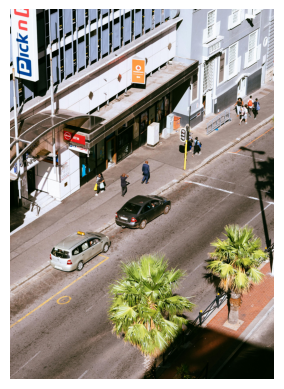

In [53]:
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

image_path = "sample_img3.jpg"
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")


In [54]:
transform = T.Compose([  # Groups multiple image transformations into a single sequence
    T.ToTensor()         # Converts a PIL Image or NumPy array (H, W, C) in range [0, 255]
                         # to a float32 torch.Tensor (C, H, W) in range [0.0, 1.0]
])

# transform(image): Applies the conversion (scaling pixels and reordering dimensions)
# .unsqueeze(0): Adds a "batch" dimension at index 0, changing shape from (C, H, W) to (1, C, H, W)
# .to(device): Moves the tensor memory to the GPU (if available) so the model can process it
img_tensor = transform(image).unsqueeze(0).to(device)

In [55]:
with torch.no_grad():  # Disables the gradient calculation engine to save memory and increase speed
    # Passes the image through the model to get detections
    predictions = model(img_tensor)


In [56]:
predictions[0].keys()


dict_keys(['boxes', 'labels', 'scores'])

In [57]:
boxes = predictions[0]['boxes'].cpu() # Transfers the detected bounding box coordinates from GPU memory to CPU memory
labels = predictions[0]['labels'].cpu() # Transfers the predicted category IDs from GPU memory to CPU memory
scores = predictions[0]['scores'].cpu() # Transfers the confidence scores (probability 0.0 to 1.0) from GPU memory to CPU memory


In [58]:
# Defines the minimum confidence level required to "trust" a detection
score_threshold = 0.5

keep = scores >= score_threshold
boxes = boxes[keep] # Filters the boxes tensor, keeping only those that met the threshold requirement
labels = labels[keep] # Filters the labels tensor, keeping only the classes associated with high-score boxes
scores = scores[keep] # Filters the scores tensor to remove all values below the 0.5 threshold


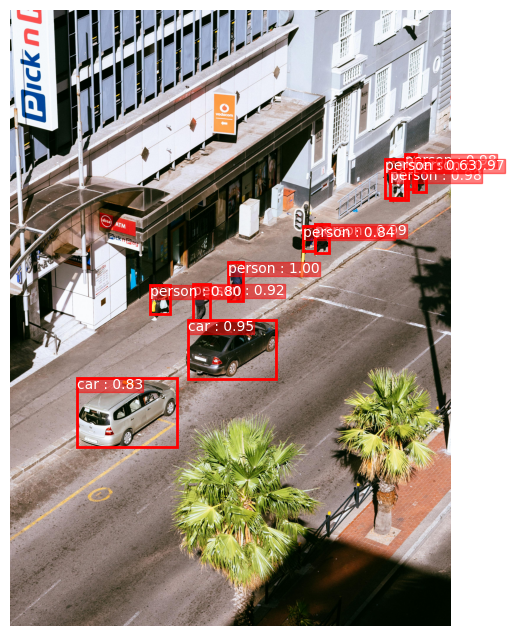

In [59]:
# A list where the index matches the numeric output of the model
# e.g., index 3 is 'car', which is what the model returns for that class
# Full list of COCO labels (91 items)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Initializes the plot area with a specific size (10 inches wide, 8 inches tall)
fig, ax = plt.subplots(1, figsize=(10, 8))

# Plots the actual pixel data of the image onto the axes
ax.imshow(image)

# Loops through all detections that passed your confidence threshold
for box, label, score in zip(boxes, labels, scores):
    x1, y1, x2, y2 = box # Unpacks coordinates: x-min, y-min, x-max, y-max

    # Defines the geometry of the bounding box
    rect = patches.Rectangle(
        (x1, y1),           # The anchor point (top-left in pixel coordinates)
        x2 - x1,            # Calculates the horizontal width
        y2 - y1,            # Calculates the vertical height
        linewidth=2,        # Sets the thickness of the box outline
        edgecolor='r',      # Sets the color to red for high visibility
        fill=False          # Keeps the box hollow so the object is visible inside
    )

    # Draws the box shape onto the image
    ax.add_patch(rect)

    # LOOKUP STEP: Converts the numeric tensor (e.g. tensor(3)) to an integer,
    # then finds the word at that position in your name list (e.g. 'car')
    label_name = COCO_INSTANCE_CATEGORY_NAMES[label.item()]

    # Overlays the text string and confidence score onto the plot at the box corner
    ax.text(x1, y1, f"{label_name} : {score:.2f}", color='white', verticalalignment='top',
            bbox={'color': 'red', 'alpha': 0.5, 'pad': 0})

# Removes the pixel coordinate rulers (0, 100, 200...) from the edges
plt.axis("off")

# Final command to render the combined image, boxes, and text to the UI
plt.show()